In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

!pip install pymongo




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 12.2 MB/s eta 0:00:00


#### **MongoDB Connection**

In [2]:
# from pymongo.mongo_client import MongoClient
# from google.colab import userdata
# mongo_uri = userdata.get('MONGO_URI')

# #creating a client to connect to server
# client = MongoClient(mongo_uri)

# db = client["Apex_trust_customer_transactions"]
# collection = db["Apex_Customer"]

# #load data into pandas dataframe
# data = list(collection.find({}))

# customer_data = pd.DataFrame(data)

# customer_data.head()

# #we notice mongoDB usually comes with a compulsory ID which is the column called _id which helps it keeps
# #track of the dataset or database incase of any update

# customer_data = customer_data.drop("_id",axis=1)

# customer_data.head()

In [3]:
# save the dataset
#customer_data.to_csv('/content/drive/MyDrive/apex_data/customer_data.csv', index=False)

Due to intermittent MongoDB connection failures and the large size of the transactional dataset, the extracted data was saved as a CSV file in Google Drive after the initial extraction process. This ensured reproducibility, reduced repeated database queries, improved workflow stability, and enabled efficient analysis without dependence on continuous database connectivity.

In [4]:
#Loading the saved csv file back to google colab to be used for analysis and segmentation

file_path = Path("/content/drive/MyDrive/apex_data/customer_data.csv")

customer_data = pd.read_csv(file_path)

customer_data.head()


,TransactionID,CustomerID,TransactionDate,TransactionTime,TransactionAmount,CustomerDOB,CustGender,CustLocation,CustAccountBalance
0,T9313390,C2867825,2022-09-03,43813,294.72,1968-10-20,M,East Lynne,13783.32
1,T3155753,C2867825,2020-05-25,160856,225.89,1968-10-20,M,East Lynne,13557.43
2,T2245710,C2867825,2022-07-31,71919,11.30,1968-10-20,M,East Lynne,13546.13
3,T1809263,C2867825,2022-08-31,32918,409.57,1968-10-20,M,East Lynne,13136.56
4,T6467293,C2867825,2022-05-21,154520,123.15,1968-10-20,M,East Lynne,13259.71


The previously extracted customer transaction dataset was loaded from Google Drive into Google Colab using a predefined file path created with Python’s Path library. The dataset was read into a Pandas DataFrame using pd.read_csv() to enable further exploratory data analysis, feature engineering, customer segmentation, and machine learning tasks. Displaying the first few rows of the dataset with .head() provided an initial preview to verify that the data was loaded successfully and correctly structured for analysis.

The MongoDB connection code was subsequently commented out after the dataset had been successfully extracted and saved locally. This was done to reduce repeated database queries, improve workflow stability, prevent connection interruptions, and ensure reproducibility throughout the analysis process.

In [5]:
#Check the dimension of the dataset
customer_data.shape

(1000000, 9)

In [6]:
#check the transaction counts of each CustomerID
customer_data["CustomerID"].value_counts()

,count
CustomerID,
C2867825,52083
C2923322,53
C8985604,52
C9906505,52
C9060593,52
...,...
C5731929,1
C2738615,1
C6744356,1


Based on the transaction frequency checks on the CustomerID column, it was observed that one customer ID (C2867825) recorded an unusually high number of transactions (52,083) compared to the rest of the dataset. This record was identified as an outlier and removed to prevent it from disproportionately influencing the dataset, skewing customer behavior patterns, and negatively affecting the accuracy and effectiveness of the segmentation process.

In [7]:
#removing the outlier CustomerID
customer_data = customer_data[customer_data['CustomerID']!= 'C2867825']

In [8]:
#view the first 5 rows
customer_data.head()

,TransactionID,CustomerID,TransactionDate,TransactionTime,TransactionAmount,CustomerDOB,CustGender,CustLocation,CustAccountBalance
52083,T9105905,C1419610,2021-06-18,74921,177.72,1991-08-13,F,East Gordonside,29923.49
52084,T3229540,C1419610,2021-07-16,145601,304.89,1991-08-13,F,East Gordonside,29618.60
52085,T5116286,C1419610,2021-01-14,113217,79.68,1991-08-13,F,East Gordonside,29538.92
52086,T4475301,C5614226,2020-04-03,72506,3685.28,1956-09-29,M,Donaldfort,62152.00
52087,T2953823,C5614226,2020-12-15,143619,5452.50,1956-09-29,M,Donaldfort,56699.50


####**Dataset Overview**

In [9]:
#Check the dimension of the dataset again
customer_data.shape

(947917, 9)

In [10]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947917 entries, 52083 to 999999
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   TransactionID       947917 non-null  object 
 1   CustomerID          947917 non-null  object 
 2   TransactionDate     947917 non-null  object 
 3   TransactionTime     947917 non-null  int64  
 4   TransactionAmount   947917 non-null  float64
 5   CustomerDOB         947917 non-null  object 
 6   CustGender          947917 non-null  object 
 7   CustLocation        947917 non-null  object 
 8   CustAccountBalance  947917 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.3+ MB


In [11]:
customer_data['CustLocation'].value_counts().reset_index()

,CustLocation,count
0,Smithmouth,740
1,Jonesmouth,694
2,Smithfort,554
3,Smithview,550
4,Smithshire,543
...,...,...
31625,North Lukemouth,1
31626,New Clareburgh,1
31627,West Heatherfurt,1
31628,West Laurenchester,1


In [12]:
print("Total number of Apex Trust Bank Customers' Location:", customer_data["CustLocation"].nunique())

Total number of Apex Trust Bank Customers' Location: 31630


In [13]:
print("The total number of customers in Apex Trust Bank:",customer_data['CustomerID'].nunique())

The total number of customers in Apex Trust Bank: 82000


In [14]:
#The gender distribution among customers in Apex Trust Bank
customer_data.groupby('CustGender')['CustomerID'].nunique().reset_index()

,CustGender,CustomerID
0,F,40968
1,M,41202


In [15]:
print("The gender distribution by customers transaction train Apex Trust Bank:", customer_data["CustGender"].value_counts())

The gender distribution by customers transaction train Apex Trust Bank: CustGender
M    474360
F    473557
Name: count, dtype: int64


In [16]:
print("Duplicated Transactions:",customer_data.duplicated().sum())

Duplicated Transactions: 0


In [17]:
print("Duplicated TransactionID:", customer_data["TransactionID"].duplicated().sum())

Duplicated TransactionID: 48431


In [18]:
print("Counts of TransactionID:", customer_data["TransactionID"].nunique())

Counts of TransactionID: 899486


In [19]:
#Checking the age range of the customers in Apex Trust Bank
print("The youngest customer in Apex Trust Bank:", customer_data["CustomerDOB"].max())
print("The oldest customer in Apex Trust Bank:", customer_data["CustomerDOB"].min())

The youngest customer in Apex Trust Bank: 2007-10-22
The oldest customer in Apex Trust Bank: 1944-10-24


In [20]:
#Checking the transaction date range
print("The most recent transaction date:", customer_data["TransactionDate"].max())
print("The oldest transaction date:", customer_data["TransactionDate"].min())

The most recent transaction date: 2022-12-31
The oldest transaction date: 2020-01-01


In [21]:
print("The largest transaction made in Apex Trust Bank:",customer_data['TransactionAmount'].max())
print("The smallest transaction made in Apex Trust Bank:",customer_data['TransactionAmount'].min())

The largest transaction made in Apex Trust Bank: 22032.73
The smallest transaction made in Apex Trust Bank: 1.0


In [22]:
print("The total transaction amount made in Apex Trust Bank:", customer_data['TransactionAmount'].sum())

The total transaction amount made in Apex Trust Bank: 1493486687.5600007


In [23]:
print("The average transaction amount made in Apex Trust Bank:", customer_data['TransactionAmount'].mean())

The average transaction amount made in Apex Trust Bank: 1575.5458416295949


In [24]:
print("The average customer account balance:", customer_data['CustAccountBalance'].mean())

The average customer account balance: 25664.14268863202


The customer transaction data was extracted from a MongoDB database server and loaded into a Pandas DataFrame for analysis. After extraction, the dataset contained 1,000,000 rows and 9 columns, indicating a large transaction-level dataset suitable for customer behavior analysis and segmentation.
Each row in the dataset represents a single customer transaction, while each customer can appear multiple times because one customer may perform several transactions over time. Therefore, the dataset follows a one-to-many relationship, where one CustomerID can be linked to many transaction records.
The main structure of the dataset includes customer identifiers, transaction details, demographic information, customer location, and account balance information. These fields support both transaction-level analysis and customer-level aggregation for segmentation.
After the initial sanity checks, the dataset showed good data quality. There were no missing values and no duplicate transactions, meaning the data was complete and reliable for further analysis.
However, one unusual customer record was identified. Customer ID C2867825 had an extremely high number of transactions, with 52,083 transaction records. This was treated as an outlier because it could distort customer behavior patterns and negatively affect the segmentation model. To prevent this customer from skewing the analysis, the record was removed from the dataset.
After removing this outlier, the dataset was reduced from 1,000,000 rows and 9 columns to 947,917 rows and 9 columns.
Gender distribution was also reviewed as part of the initial data understanding. The transaction count by gender was almost balanced, with 474,360 male customer transactions and 473,557 female customer transactions. When looking at unique customers rather than transaction records, there were 41,202 male customers and 40,968 female customers. This shows that the dataset is fairly balanced across gender groups, reducing the risk of gender imbalance affecting the segmentation analysis.

#### **Data Cleaning & Preprocessing**

In [25]:
#Total sum of missing data
customer_data.isna().sum()

,0
TransactionID,0
CustomerID,0
TransactionDate,0
TransactionTime,0
TransactionAmount,0
CustomerDOB,0
CustGender,0
CustLocation,0
CustAccountBalance,0


In [26]:
#Checking for data types
customer_data.dtypes

,0
TransactionID,object
CustomerID,object
TransactionDate,object
TransactionTime,int64
TransactionAmount,float64
CustomerDOB,object
CustGender,object
CustLocation,object
CustAccountBalance,float64


The TransactionDate and CustomerDOB columns are stored as object data types and need to be converted to datetime format for proper time-based analysis. The TransactionTime column, stored as an integer, also requires transformation into a time or datetime format.

In [27]:
#converting to datetime
customer_data['TransactionDate'] = pd.to_datetime(customer_data['TransactionDate'], errors='coerce')
customer_data['CustomerDOB'] = pd.to_datetime(customer_data['CustomerDOB'], errors='coerce')

In [28]:
# Convert to int first to strip decimals, then string, then pad
customer_data['TransactionTime'] = pd.to_datetime(
    customer_data['TransactionTime'].astype(str).str.strip().str.zfill(6),
    format='%H%M%S',
    errors='coerce'
).dt.time

In [29]:
#rechecking the dataset
customer_data.head()

,TransactionID,CustomerID,TransactionDate,TransactionTime,TransactionAmount,CustomerDOB,CustGender,CustLocation,CustAccountBalance
52083,T9105905,C1419610,2021-06-18,07:49:21,177.72,1991-08-13,F,East Gordonside,29923.49
52084,T3229540,C1419610,2021-07-16,14:56:01,304.89,1991-08-13,F,East Gordonside,29618.60
52085,T5116286,C1419610,2021-01-14,11:32:17,79.68,1991-08-13,F,East Gordonside,29538.92
52086,T4475301,C5614226,2020-04-03,07:25:06,3685.28,1956-09-29,M,Donaldfort,62152.00
52087,T2953823,C5614226,2020-12-15,14:36:19,5452.50,1956-09-29,M,Donaldfort,56699.50


In [30]:
#checking the dimension again
customer_data.shape

(947917, 9)

In [31]:
#checking the info again
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 947917 entries, 52083 to 999999
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   TransactionID       947917 non-null  object        
 1   CustomerID          947917 non-null  object        
 2   TransactionDate     947917 non-null  datetime64[ns]
 3   TransactionTime     947917 non-null  object        
 4   TransactionAmount   947917 non-null  float64       
 5   CustomerDOB         947917 non-null  datetime64[ns]
 6   CustGender          947917 non-null  object        
 7   CustLocation        947917 non-null  object        
 8   CustAccountBalance  947917 non-null  float64       
dtypes: datetime64[ns](2), float64(2), object(5)
memory usage: 72.3+ MB


In [32]:
#checking for missing values again
customer_data.isna().sum()

,0
TransactionID,0
CustomerID,0
TransactionDate,0
TransactionTime,0
TransactionAmount,0
CustomerDOB,0
CustGender,0
CustLocation,0
CustAccountBalance,0


In [33]:
#checking for duplicates again
customer_data.duplicated().sum()

np.int64(0)

The TransactionTime column was originally stored as an integer in HHMMSS format. After testing datetime conversion, the column produced invalid NaT values due to parsing issues. To preserve the original information and avoid introducing artificial missing values, the column was retained as a cleaned object/string time field as I plan to extract useful time-based features for analysis in the feature engineering stage.

After converting the date columns (TransactionDate,TransactionTime, CustomerDOB), did another checks for missing values, datatypes and duplicates. There are no missing values in the dataset, no duplicates and all columns are in the right datatypes.

### **Exploratory Data Analysis**

In [34]:
# creating the descriptive summary statistics
customer_data.describe().round(2)

,TransactionDate,TransactionAmount,CustomerDOB,CustAccountBalance
count,947917,947917.00,947917,947917.00
mean,2021-06-30 20:18:27.636216832,1575.55,1976-05-14 21:07:41.079609248,25664.14
min,2020-01-01 00:00:00,1.00,1944-10-24 00:00:00,0.00
25%,2020-09-30 00:00:00,44.83,1960-09-18 00:00:00,2760.07
50%,2021-07-01 00:00:00,66.36,1976-04-29 00:00:00,11664.62
75%,2022-04-01 00:00:00,3238.68,1992-01-30 00:00:00,33544.89
max,2022-12-31 00:00:00,22032.73,2007-10-22 00:00:00,456249.98
std,NaN,2670.82,NaN,36565.25


##### **Gender Analysis**

In [35]:
#checking customer statistics by gender
gender_statistics = customer_data.groupby('CustGender').agg({"CustomerID":"nunique",
                                                            "CustAccountBalance":"mean",
                                                            "TransactionAmount":["mean", "sum", "count"]})

gender_statistics.columns=["TotalCustomers","AverageBalance","AverageAmount","TotalAmount","TransactionCount"]
gender_statistics.reset_index()

,CustGender,TotalCustomers,AverageBalance,AverageAmount,TotalAmount,TransactionCount
0,F,40968,25816.927858,1561.541757,7.394790e+08,473557
1,M,41202,25511.616155,1589.526220,7.540077e+08,474360


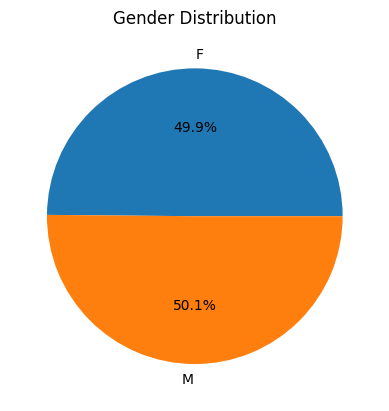

In [36]:
plt.pie(gender_statistics['TotalCustomers'], labels=gender_statistics.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.savefig('/content/drive/MyDrive/apex_plots/gender_distribution.png')
plt.show()

The gender distribution chart shows that the customer base is almost perfectly balanced between male and female customers. Male customers account for approximately 50.1% of the dataset, while female customers represent about 49.9%.

This near-equal distribution indicates that the dataset does not suffer from significant gender imbalance, which is beneficial for unbiased analysis and customer segmentation. It also suggests that ApexTrust Bank’s customer base is broadly representative across both genders, allowing behavioral comparisons and segmentation insights to be generated without one gender disproportionately influencing the results.

From an analytical perspective, the balanced distribution improves the reliability of gender-based comparisons in areas such as transaction behavior, account balances, customer engagement, and financial activity patterns. Overall, the chart indicates that both male and female customers contribute almost equally to the bank’s transactional ecosystem.

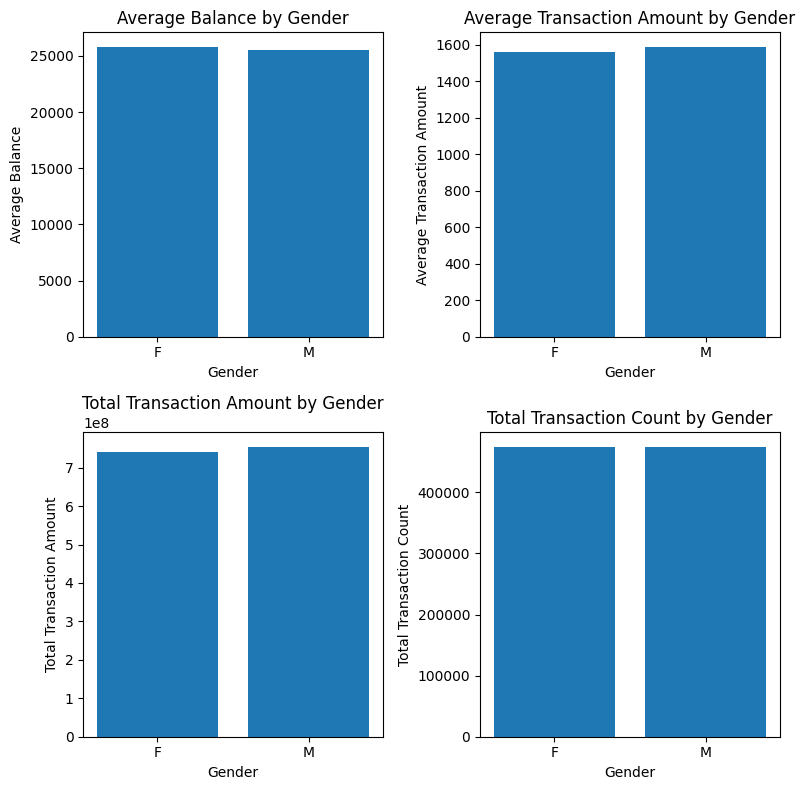

In [37]:
plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.bar(gender_statistics.index, gender_statistics['AverageBalance'])
plt.title('Average Balance by Gender')
plt.ylabel('Average Balance')
plt.xlabel('Gender')

plt.subplot(2,2,2)
plt.bar(gender_statistics.index, gender_statistics['AverageAmount'])
plt.title('Average Transaction Amount by Gender')
plt.ylabel('Average Transaction Amount')
plt.xlabel('Gender')


plt.subplot(2,2,3)
plt.bar(gender_statistics.index, gender_statistics['TotalAmount'])
plt.title('Total Transaction Amount by Gender')
plt.ylabel('Total Transaction Amount')
plt.xlabel('Gender')

plt.subplot(2,2,4)
plt.bar(gender_statistics.index, gender_statistics['TransactionCount'])
plt.title('Total Transaction Count by Gender')
plt.ylabel('Total Transaction Count')
plt.xlabel('Gender')

plt.savefig('/content/drive/MyDrive/apex_plots/gender_analysis.png')
plt.tight_layout()
plt.show()


The gender-based analysis provides insight into how male and female customers compare in terms of account balances, transaction behavior, and overall engagement with the bank’s services.

Average Balance by Gender

The chart shows that both male and female customers maintain relatively similar average account balances. Female customers appear to have a slightly higher average balance compared to male customers, although the difference is minimal. This suggests that financial holding capacity is fairly balanced across genders, indicating no major disparity in average customer wealth within the dataset.

Average Transaction Amount by Gender

The average transaction amount chart indicates that male customers have a marginally higher average transaction amount than female customers. However, the difference is relatively small, showing that both genders exhibit similar spending and transaction behavior patterns. This suggests that transaction value alone may not strongly differentiate customer behavior between male and female customers.

Total Transaction Amount by Gender

The total transaction amount chart reveals that male customers contributed a slightly higher total transaction value compared to female customers. This is likely influenced by the slightly higher number of male customers and transaction activity within the dataset. Nevertheless, the overall transaction contribution between both genders remains relatively balanced.

Total Transaction Count by Gender

The total transaction count chart shows that transaction activity is almost evenly distributed between male and female customers, with male customers recording only a slightly higher number of transactions. This aligns with the earlier observation that the dataset itself is fairly balanced in terms of gender representation.

Overall, the analysis suggests that customer transaction behavior is relatively similar across both genders. Differences in average balance, transaction amount, and transaction frequency are minor, indicating that gender alone may not be a strong distinguishing factor in customer financial behavior within the bank.

##### **Location Analysis**

In [38]:
location_statistics = customer_data.groupby('CustLocation').agg({"CustomerID":"nunique",
                                                              "CustAccountBalance":"mean",
                                                              "TransactionAmount":["mean", "sum", "count"]}).round(2)

location_statistics.columns=["UniqueCustomers","AverageBalance","AverageAmount","TotalAmount","TransactionCount"]
location_statistics = location_statistics.sort_values(by="UniqueCustomers", ascending=False).reset_index()
top_10_locations = location_statistics.head(10)
bottom_10_locations = location_statistics.tail(10)
top_10_locations

,CustLocation,UniqueCustomers,AverageBalance,AverageAmount,TotalAmount,TransactionCount
0,Smithmouth,61,26192.95,825.04,610531.79,740
1,Jonesmouth,51,26333.92,876.93,608588.26,694
2,Smithfort,47,23000.11,931.32,515952.69,554
3,Smithview,45,32302.52,1195.53,657543.52,550
4,Smithburgh,43,32211.87,1474.94,768441.27,521
5,Smithshire,39,22706.55,2250.68,1222119.89,543
6,Smithton,37,25550.45,1893.20,586892.70,310
7,Smithfurt,35,26072.38,1153.96,491589.07,426
8,Smithside,34,23809.77,915.38,432057.53,472
9,Smithbury,33,28611.48,1425.92,550405.83,386


In [39]:
bottom_10_locations

,CustLocation,UniqueCustomers,AverageBalance,AverageAmount,TotalAmount,TransactionCount
31620,New Jamiechester,1,9630.02,5572.41,61296.49,11
31621,New Jamesville,1,23684.20,51.42,1439.79,28
31622,New Jamesstad,1,5517.10,157.74,473.23,3
31623,New Jamesmouth,1,4650.36,57.23,1316.38,23
31624,New Jamesland,1,992.71,108.34,108.34,1
31625,New Jamesborough,1,1789.50,179.11,537.33,3
31626,East Davidville,1,2936.80,168.17,504.52,3
31627,East Davidview,1,3168.69,47.54,950.70,20
31628,East Davidstad,1,122351.28,4742.33,80619.67,17
31629,East Davidport,1,1284.74,66.65,1199.67,18


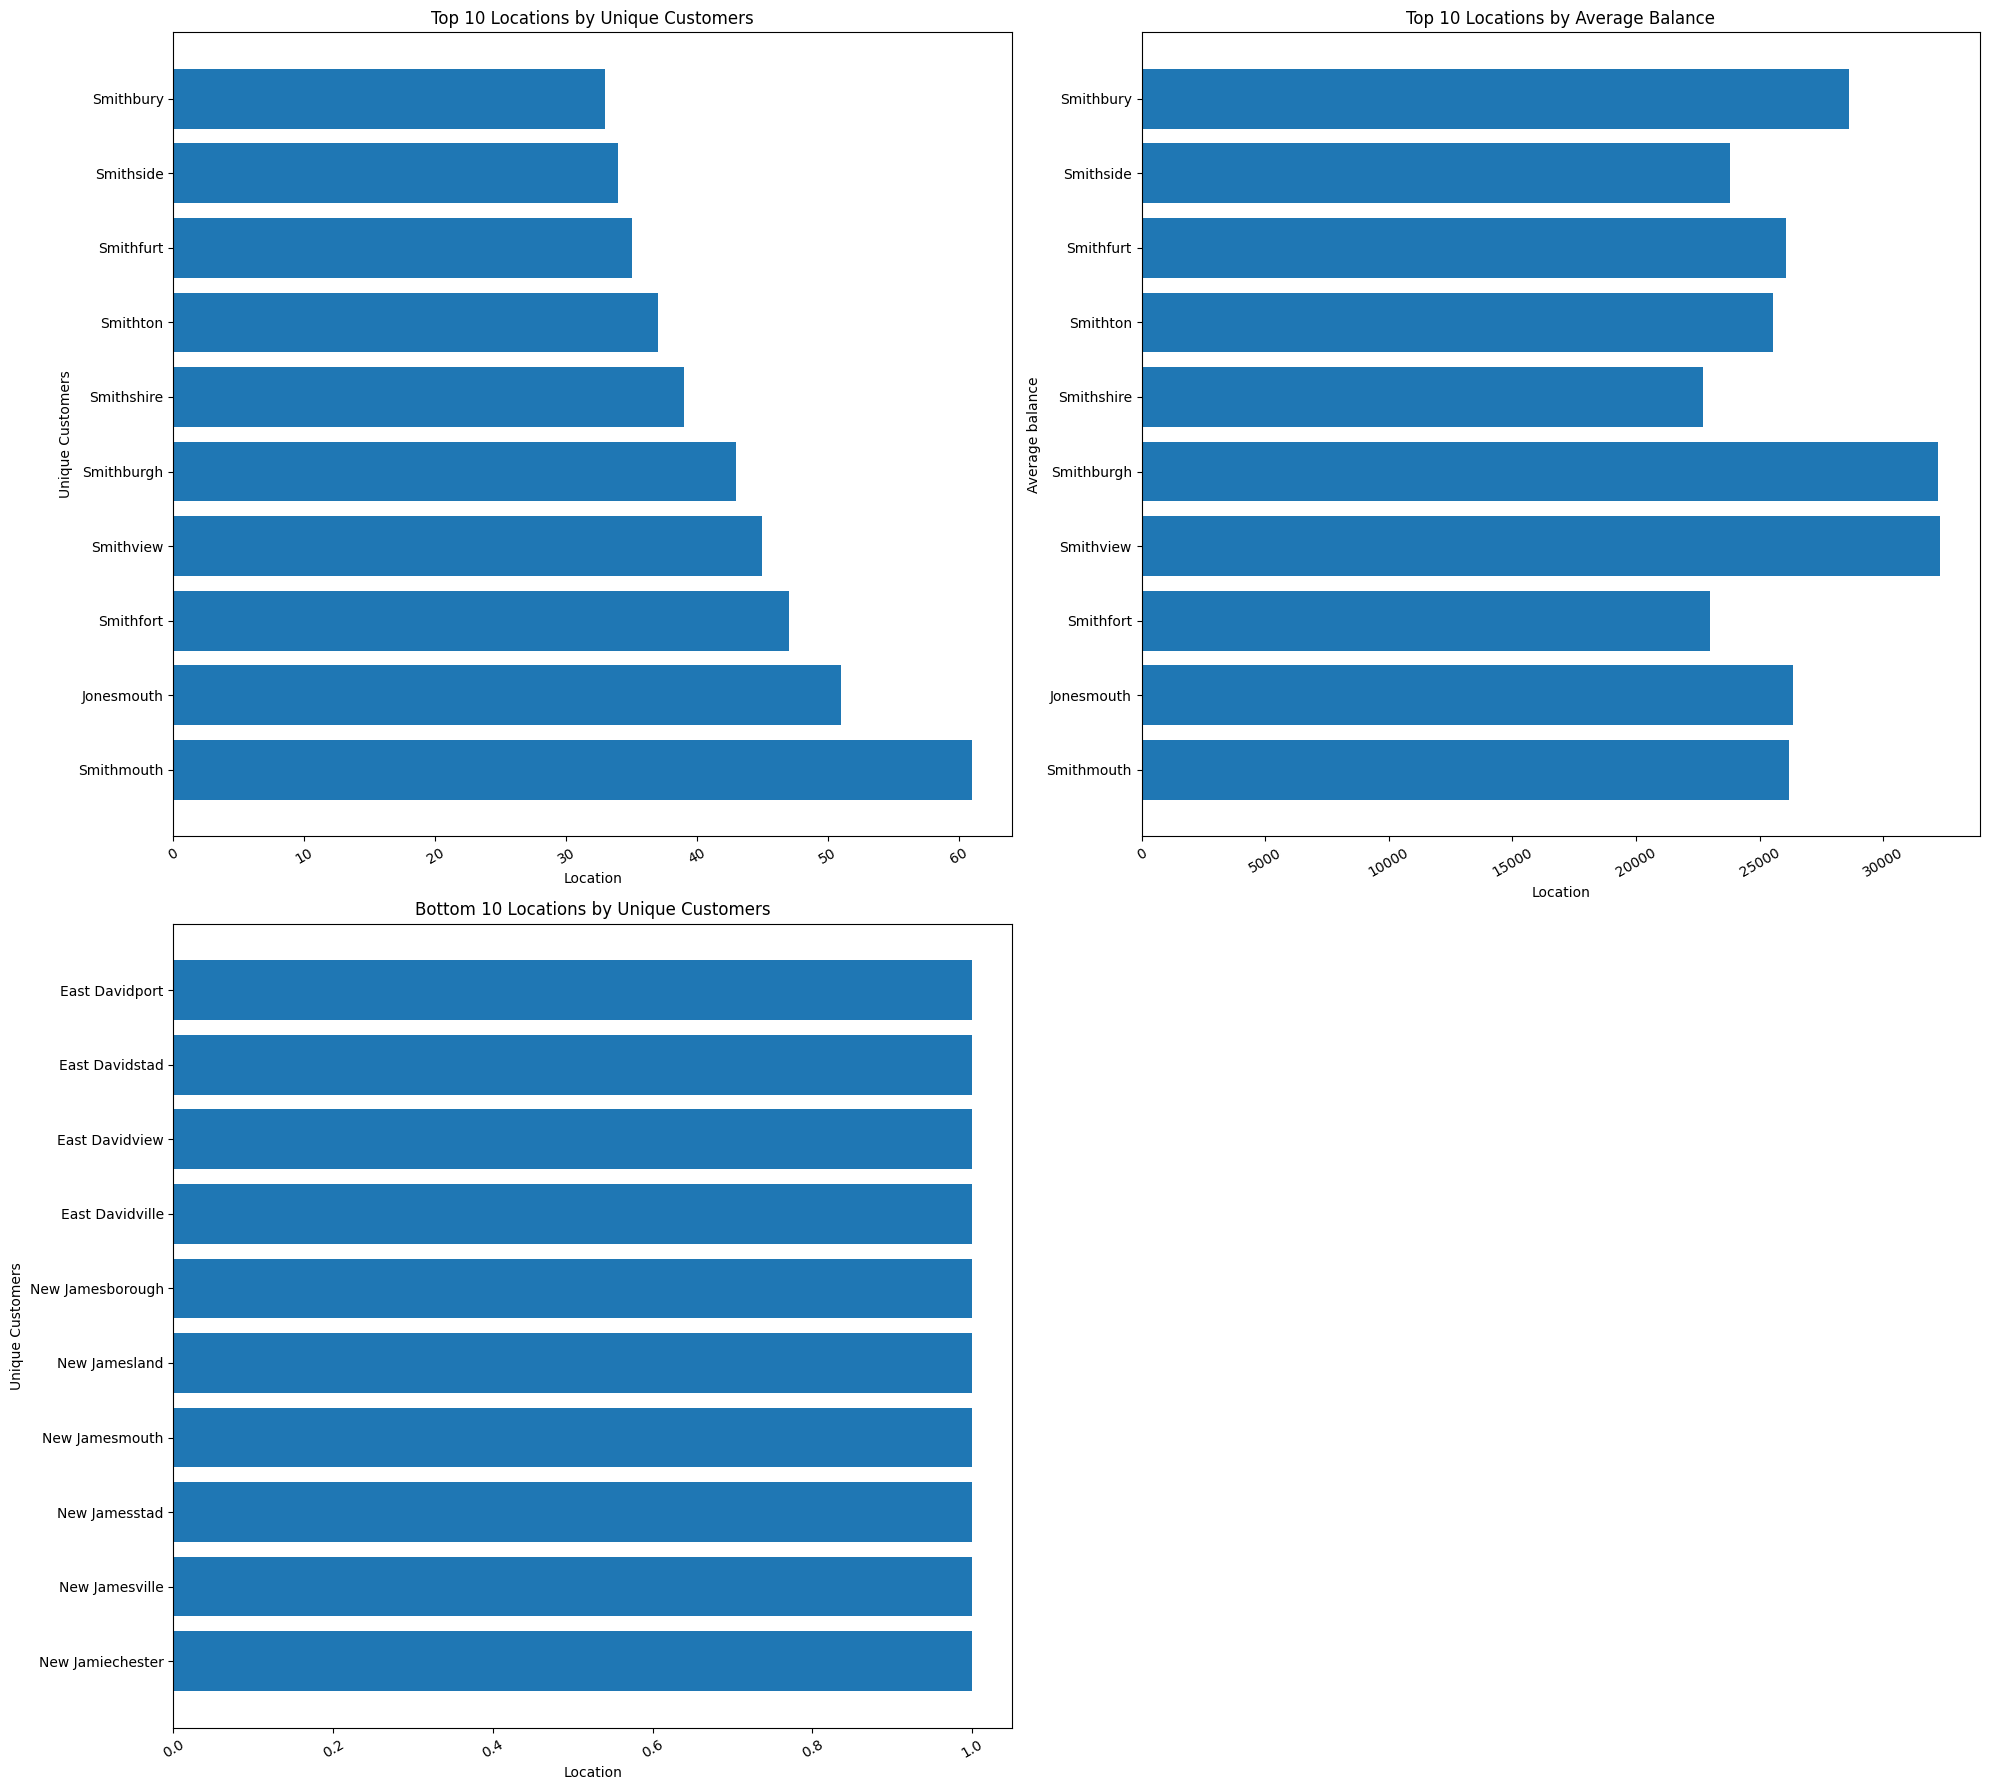

In [40]:
plt.figure(figsize=(20,18))

plt.subplot(2,2,1)
plt.barh(top_10_locations['CustLocation'], top_10_locations['UniqueCustomers'])
plt.title('Top 10 Locations by Unique Customers')
plt.ylabel('Unique Customers')
plt.xlabel('Location')
plt.xticks(rotation = 30)

plt.subplot(2,2,2)
plt.barh(top_10_locations['CustLocation'], top_10_locations['AverageBalance'])
plt.title('Top 10 Locations by Average Balance')
plt.ylabel('Average balance')
plt.xlabel('Location')
plt.xticks(rotation = 30)

plt.subplot(2,2,3)
plt.barh(bottom_10_locations['CustLocation'], bottom_10_locations['UniqueCustomers'])
plt.title("Bottom 10 Locations by Unique Customers")
plt.ylabel('Unique Customers')
plt.xlabel('Location')
plt.xticks(rotation = 30)

plt.savefig('/content/drive/MyDrive/apex_plots/location_analysis.png')
plt.tight_layout()
plt.show()

The location-based analysis provides insight into the geographic distribution of customers and the variation in customer financial behavior across different regions.

Top 10 Locations by Unique Customers

The first chart highlights the locations with the highest number of unique customers. Smithmouth recorded the largest customer base among all locations, followed by Jonesmouth and Smithfort. These locations appear to represent the bank’s strongest customer concentration areas, suggesting higher market penetration and customer adoption within these regions. The gradual decline across the remaining locations indicates a relatively distributed customer base rather than an extreme concentration in a single city.

Top 10 Locations by Average Balance

The second chart shows the locations with the highest average customer account balances. Smithview and Smithburgh recorded the highest average balances, slightly exceeding other locations such as Smithmouth and Jonesmouth. This suggests that although some locations may not necessarily have the highest customer counts, they may still contain customers with stronger financial positions or higher-value accounts. The variation in average balances across locations highlights regional differences in customer financial capacity and banking behavior.

Bottom 10 Locations by Unique Customers

The third chart presents locations with the lowest number of unique customers. Several locations, including New Jamiechester, New Jamesville, and East Davidport, recorded only a single unique customer. This suggests extremely low customer representation in these areas, which may indicate regions where the bank has limited market presence, low customer adoption, or potentially newly emerging customer locations.

Overall Insight

The analysis reveals clear geographic differences in customer concentration and financial behavior. Some locations contribute significantly larger customer populations, while others contribute stronger average account balances. This indicates that customer value is not solely dependent on customer volume but also on the financial characteristics of customers within each region.

These insights can support strategic business decisions such as:

identifying high-value geographic markets,
improving regional marketing strategies,
targeting customer acquisition efforts in underrepresented locations,
and tailoring financial products based on regional customer behavior patterns.

Overall, location appears to be an important demographic feature that could contribute valuable information during customer segmentation and profiling.

#### **Age Analysis**

In this analysis, we are trying to know the age of the customers and their behaviour

In [41]:
#creating the age column from the customers date of birth

current_year = datetime.now().year

customer_data['Age'] = (current_year - customer_data['CustomerDOB'].dt.year)
#remove negative ages and unrealistic age
customer_data = customer_data[(customer_data['Age'] >= 18) & (customer_data['Age'] <= 100)]
customer_data[['CustomerDOB', 'Age']].head(10)


,CustomerDOB,Age
52083,1991-08-13,35
52084,1991-08-13,35
52085,1991-08-13,35
52086,1956-09-29,70
52087,1956-09-29,70
52088,1956-09-29,70
52089,1956-09-29,70
52090,1956-09-29,70
52091,1956-09-29,70
52092,1956-09-29,70


In [42]:
customer_data['Age'].value_counts().reset_index()

,Age,count
0,55,16641
1,37,16122
2,47,16116
3,53,15911
4,56,15849
...,...,...
59,77,13974
60,40,13907
61,65,13907
62,19,12497


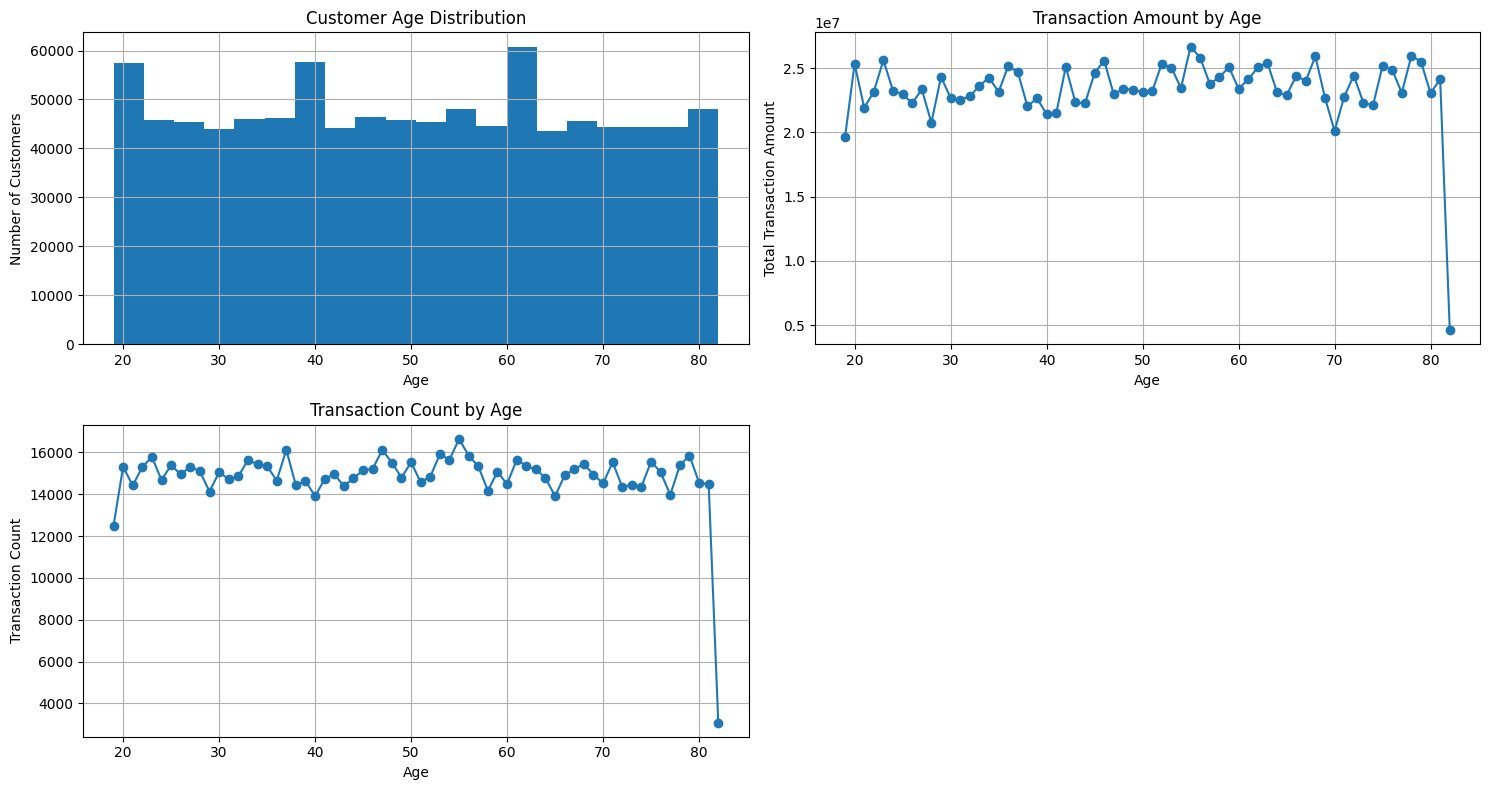

In [43]:
#visualization
plt.figure(figsize=(15,8))
#Age distribution
plt.subplot(2,2,1)
plt.hist(customer_data['Age'], bins=20)
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.title('Customer Age Distribution')
plt.grid(True)

#Transaction Amount by Age
age_amount = customer_data.groupby('Age')['TransactionAmount'].sum()
plt.subplot(2,2,2)
plt.plot(age_amount.index, age_amount.values, marker='o')
plt.xlabel('Age')
plt.ylabel('Total Transaction Amount')
plt.title('Transaction Amount by Age')
plt.grid(True)

#Transaction Count by Age
age_count = customer_data.groupby('Age')['TransactionID'].count()
plt.subplot(2,2,3)
plt.plot(age_count.index, age_count.values, marker='o')
plt.xlabel('Age')
plt.ylabel('Transaction Count')
plt.title('Transaction Count by Age')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/apex_plots/age_analysis.png')
plt.show()

Customer Age Distribution

The age distribution chart shows that customers are fairly evenly distributed across most age groups between approximately 20 and 80 years old, with no extreme concentration in a single age bracket. However, there are slightly higher customer counts around the early 20s, late 30s, and early 60s, suggesting that these age groups form a larger proportion of the bank’s customer base. Overall, the bank appears to serve a broad and balanced age demographic rather than being dominated by a particular generation.

Transaction Amount by Age

The transaction amount chart indicates that total transaction values remain relatively stable across most age groups. Customers between the ages of roughly 20 and 80 contribute consistently high transaction volumes, suggesting that financial activity is broadly distributed across different age categories. There are moderate fluctuations in transaction value across ages, but no major spikes or declines until the very last age value, where there is a sharp drop. This sharp decline is likely caused by a very small number of customers in that age category, making the aggregated transaction amount much lower compared to the rest of the dataset.

Transaction Count by Age

The transaction count chart shows a similar trend to the transaction amount chart. Most age groups exhibit relatively consistent transaction frequencies, indicating that customer engagement with banking services remains stable across different ages. Customers in middle-aged and older adult categories appear slightly more active in terms of transaction frequency. Similar to the previous chart, the final age category shows a sharp decline in transaction count, which is likely due to fewer customers existing within that age bracket rather than a genuine behavioral trend.

The charts collectively suggest that customer transaction behavior is relatively balanced across age groups, with no single age category overwhelmingly dominating transaction activity. This implies that the bank’s services are widely utilized across multiple demographic segments. The consistency in both transaction amount and transaction count across ages also indicates that age alone may not be a strong differentiator of customer value, reinforcing the importance of combining demographic attributes with behavioral metrics such as Recency, Frequency, and Monetary (RFM) values during customer segmentation.

#### **Transaction analysis**

In [44]:
# Top 10 Customers by Transaction Amount
top_customers = customer_data.groupby('CustomerID').agg({'TransactionAmount': ['sum', 'count', 'mean'],
                                                         'CustAccountBalance': 'last',
                                                         'CustGender':'first',
                                                         'CustLocation':'first'}).round(2)



top_customers.columns = ['TotalAmount', 'TransactionCount', 'AverageAmount', 'LastBalance', 'Gender', 'Location']
top_customers = top_customers.sort_values(by='TotalAmount', ascending=False).reset_index()
top_customers = top_customers.head(10)
print("Top 10 Customers:")
top_customers


Top 10 Customers:


,CustomerID,TotalAmount,TransactionCount,AverageAmount,LastBalance,Gender,Location
0,C4616926,238187.91,46,5178.00,0.00,F,Lake Williamside
1,C2162054,209987.63,37,5675.34,0.00,M,Port Terryville
2,C4510031,208411.26,39,5343.88,0.00,M,East Kevin
3,C4986191,196913.72,43,4579.39,0.00,F,Bretthaven
4,C4626616,181808.96,35,5194.54,10675.14,F,Lisaburgh
5,C1906432,178699.80,37,4829.72,0.00,M,Rosstown
6,C2409527,161884.66,31,5222.09,0.00,M,Mauriceside
7,C6585409,160858.58,33,4874.50,18547.11,F,West Jayne
8,C5779944,158521.00,34,4662.38,7481.76,F,Port Jasonhaven
9,C1482732,144832.22,29,4994.21,35180.27,M,North Lawrencemouth


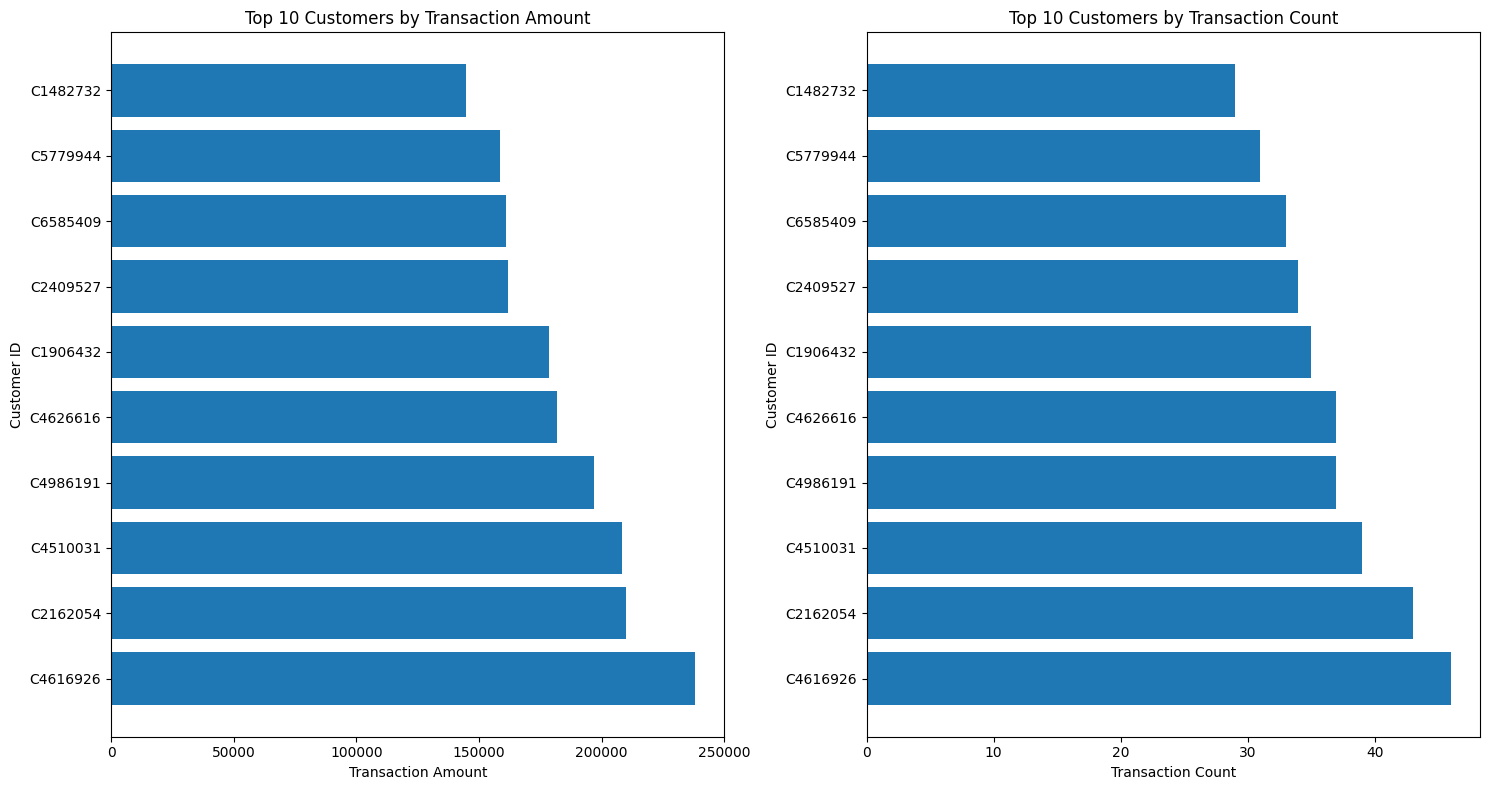

In [45]:
#visualization
plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
plt.barh(top_customers['CustomerID'], top_customers['TotalAmount'])
plt.title('Top 10 Customers by Transaction Amount')
plt.ylabel('Customer ID')
plt.xlabel('Transaction Amount')


plt.subplot(1,2,2)
top_customers_count = top_customers.sort_values(by='TransactionCount', ascending=False).head(10)
plt.barh(top_customers['CustomerID'], top_customers_count['TransactionCount'])
plt.title('Top 10 Customers by Transaction Count')
plt.ylabel('Customer ID')
plt.xlabel('Transaction Count')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/apex_plots/top_customers.png')
plt.show()

The customer-level transaction analysis identifies the most active and highest-value customers within the dataset based on transaction amount and transaction frequency.

Top 10 Customers by Transaction Amount

The first chart highlights the customers who contributed the highest total transaction amounts. Customer C4616926 recorded the highest transaction value, significantly exceeding the other customers in the top 10 list. Other customers such as C2162054 and C4510031 also contributed substantial transaction volumes. These customers can be considered high-value customers because they contribute a larger share of the bank’s transactional revenue and financial activity.

Top 10 Customers by Transaction Count

The second chart identifies customers with the highest number of transactions. Customer C4616926 again ranked highest, indicating both high transaction frequency and high transaction value. Other customers such as C2162054, C4510031, and C4986191 also demonstrated strong transaction activity. Customers appearing in both charts may represent highly engaged and financially active customers who frequently interact with the bank’s services.

The analysis reveals that a relatively small group of customers contributes disproportionately to transaction activity and transaction value. Customers who rank highly in both transaction amount and transaction count may represent premium or highly engaged customer segments. These customers could be important targets for customer retention strategies, personalized financial products, loyalty programs, and relationship management initiatives.

Overall, the charts provide valuable insight into customer value distribution and highlight the importance of identifying high-performing customers during the customer segmentation process.

#### **Temporal Analysis**

In this analysis, we will create some columns from TransactionDate. These are TransactionMonth, TransactionDay and TransactionHour from TransactionTime

In [46]:
customer_data.head()

,TransactionID,CustomerID,TransactionDate,TransactionTime,TransactionAmount,CustomerDOB,CustGender,CustLocation,CustAccountBalance,Age
52083,T9105905,C1419610,2021-06-18,07:49:21,177.72,1991-08-13,F,East Gordonside,29923.49,35
52084,T3229540,C1419610,2021-07-16,14:56:01,304.89,1991-08-13,F,East Gordonside,29618.60,35
52085,T5116286,C1419610,2021-01-14,11:32:17,79.68,1991-08-13,F,East Gordonside,29538.92,35
52086,T4475301,C5614226,2020-04-03,07:25:06,3685.28,1956-09-29,M,Donaldfort,62152.00,70
52087,T2953823,C5614226,2020-12-15,14:36:19,5452.50,1956-09-29,M,Donaldfort,56699.50,70


In [47]:
#Temporal Analysis
customer_data['TransactionYear'] = customer_data['TransactionDate'].dt.year
customer_data['TransactionMonth'] = customer_data['TransactionDate'].dt.month
customer_data['TransactionDay'] = customer_data['TransactionDate'].dt.day

customer_data['TransactionTime'] = customer_data['TransactionTime'].astype(str)

customer_data['TransactionHour'] = customer_data['TransactionTime'].str[:2].astype(int)

# Monthly trends
monthly_trends = customer_data.groupby(['TransactionYear','TransactionMonth']).agg({'TransactionAmount': 'sum', 'TransactionID':'count', 'CustomerID':'nunique'}).round(2)

monthly_trends.columns = ['TotalAmount', 'TransactionCount', 'UniqueCustomers']
monthly_trends.reset_index(inplace=True)
print("monthly_trends:")
monthly_trends


monthly_trends:


,TransactionYear,TransactionMonth,TotalAmount,TransactionCount,UniqueCustomers
0,2020,1,42471228.97,26843,21261
1,2020,2,39642341.92,25312,20292
2,2020,3,43609425.61,27176,21520
3,2020,4,40892395.44,26005,20892
4,2020,5,42499949.33,27103,21446
5,2020,6,40349128.88,25986,20692
6,2020,7,42018834.17,26736,21222
7,2020,8,42312360.60,26864,21301
8,2020,9,40599954.81,25782,20630
9,2020,10,42930840.34,26637,21325


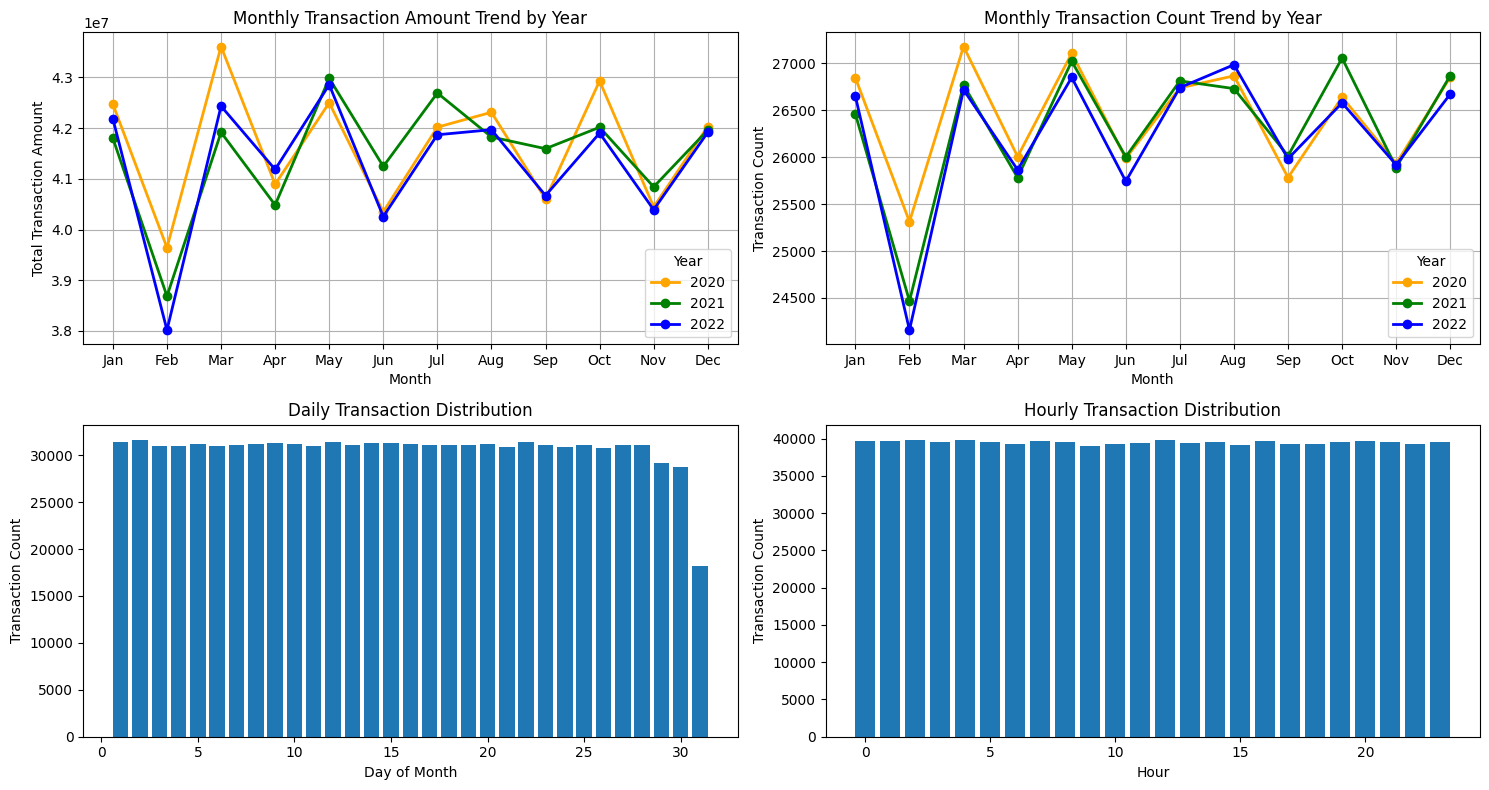

In [48]:
#visualization
plt.figure(figsize=(15,8))

#Transaction Amount Trend by Month & Year
plt.subplot(2,2,1)
colors = {2020: 'orange', 2021: 'green', 2022: 'blue'}
for year in monthly_trends['TransactionYear'].unique():
    yearly_data = monthly_trends[monthly_trends['TransactionYear'] == year]
    plt.plot(yearly_data['TransactionMonth'], yearly_data['TotalAmount'], marker='o', linewidth=2, color=colors.get(year),label=str(year))
month_names = [calendar.month_abbr[i] for i in range(1,13)]
plt.xticks(range(1,13), month_names)
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount')
plt.title('Monthly Transaction Amount Trend by Year')
plt.legend(title='Year')
plt.grid(True)

#Transaction Count Trend by Month & Year
plt.subplot(2,2,2)
for year in monthly_trends['TransactionYear'].unique():
    yearly_data = monthly_trends[monthly_trends['TransactionYear'] == year]
    plt.plot(yearly_data['TransactionMonth'],yearly_data['TransactionCount'],marker='o',linewidth=2,color=colors.get(year),label=str(year))
month_names = [calendar.month_abbr[i] for i in range(1,13)]
plt.xticks(range(1,13), month_names)
plt.xlabel('Month')
plt.ylabel('Transaction Count')
plt.title('Monthly Transaction Count Trend by Year')
plt.legend(title='Year')
plt.grid(True)


# Daily distribution
plt.subplot(2,2,3)
day_distribution = customer_data['TransactionDay'].value_counts().reset_index()
day_distribution.columns = ['Day', 'Count']

# sort days properly
day_distribution = day_distribution.sort_values(by='Day')
plt.bar(day_distribution['Day'], day_distribution['Count'])
plt.title('Daily Transaction Distribution')
plt.xlabel('Day of Month')
plt.ylabel('Transaction Count')

#Hour distribution
plt.subplot(2,2,4)
hour_distribution = customer_data['TransactionHour'].value_counts().reset_index()
hour_distribution.columns = ['hour', 'count']
# sort days properly
hour_distribution = hour_distribution.sort_values(by='hour')
plt.bar(hour_distribution['hour'], hour_distribution['count'])
plt.title('Hourly Transaction Distribution')
plt.xlabel('Hour')
plt.ylabel('Transaction Count')

plt.savefig('/content/drive/MyDrive/apex_plots/monthly_trends.png')
plt.tight_layout()
plt.show()

The transaction trend analysis provides insight into how customer financial activity changes across different months, days, and hours over the observed years.

Monthly Transaction Amount Trend by Year

The monthly transaction amount trend shows that transaction values remain relatively stable across the three years (2020, 2021, and 2022), with only moderate fluctuations between months. Across all years, February recorded one of the lowest transaction amounts, while months such as March, May, July, and October showed stronger transaction activity. The similarity of the trend lines across years suggests that customer spending behavior remains fairly consistent over time, indicating stable customer engagement and financial activity within the bank.

The peaks observed in certain months may reflect seasonal financial behavior, such as salary cycles, holiday spending, investment activity, or increased commercial transactions during specific periods of the year.

Monthly Transaction Count Trend by Year

The monthly transaction count trend closely mirrors the transaction amount trend, showing that customer transaction frequency is also relatively consistent across years. February consistently recorded the lowest transaction counts, while months such as March, May, August, October, and December showed higher transaction activity. This suggests that both the value and frequency of customer transactions follow similar seasonal patterns.

The close alignment between transaction count and transaction amount trends indicates that increases in transaction value are generally driven by higher customer activity rather than isolated large transactions.

Daily Transaction Distribution

The daily transaction distribution chart shows that transaction counts are relatively uniform across most days of the month. Most days recorded transaction counts around the same range, indicating stable customer activity throughout the month. However, the final day of the month recorded a noticeably lower transaction count compared to the other days.

This sharp decline is likely caused by differences in calendar structure, as not every month contains the 31st day. Consequently, fewer total observations exist for that date, resulting in lower transaction frequency.

Overall, the chart suggests that customers transact consistently throughout the month without strong concentration on specific dates.

Hourly Transaction Distribution

The hourly transaction distribution chart reveals that customer transactions are evenly distributed across the 24-hour cycle, with only slight variations between hours. No single hour overwhelmingly dominates transaction activity, indicating that customers interact with banking services throughout the day.

This relatively balanced hourly pattern may reflect the convenience of digital banking platforms, mobile banking applications, and automated transaction systems that allow customers to perform financial activities at any time.

Overall, the charts suggest that customer transaction behavior remains relatively stable across time dimensions, including years, months, days, and hours. Although there are moderate seasonal fluctuations in transaction volume and frequency, no extreme volatility is observed. This consistency indicates a mature and active customer base with steady engagement patterns.


### **Feature Engineering**

In [49]:
reference_date = customer_data['TransactionDate'].max() + pd.Timedelta(days=1)
print(f"reference date of the total bank transaction history: {reference_date}")


reference date of the total bank transaction history: 2023-01-01 00:00:00


In [50]:
rfm_data = customer_data.groupby('CustomerID').agg({'TransactionDate': lambda x: (reference_date - x.max()).days,
                                                    'TransactionID': 'count',
                                                  'TransactionAmount': 'sum'}).round(2).reset_index()

rfm_data.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm_data.head()

,CustomerID,Recency,Frequency,Monetary
0,C1000107,1040,1,96.41
1,C1000111,8,19,989.46
2,C1000159,106,16,758.07
3,C1000852,178,26,1455.31
4,C1000896,56,14,65914.10


In [51]:
rfm_data['CustomerID'].nunique()

82000

In [52]:
#customer demographics
customer_demographics = customer_data.groupby('CustomerID').agg({'CustomerDOB':'first', 'CustGender':'first', 'CustLocation':'first', 'CustAccountBalance':'last'}).reset_index()

customer_demographics.head()

,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance
0,C1000107,2001-06-27,F,South Josh,1150.66
1,C1000111,1952-11-18,M,New Peter,52895.11
2,C1000159,1988-07-23,M,Lake Duncanburgh,3006.98
3,C1000852,1985-10-06,M,Thomasborough,11922.49
4,C1000896,1945-04-10,M,East Kim,43815.21


In [53]:
#merging both customer demographics table and rfm_data table
rfm_df = pd.merge(rfm_data, customer_demographics, on='CustomerID', how='outer')
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,CustomerDOB,CustGender,CustLocation,CustAccountBalance
0,C1000107,1040,1,96.41,2001-06-27,F,South Josh,1150.66
1,C1000111,8,19,989.46,1952-11-18,M,New Peter,52895.11
2,C1000159,106,16,758.07,1988-07-23,M,Lake Duncanburgh,3006.98
3,C1000852,178,26,1455.31,1985-10-06,M,Thomasborough,11922.49
4,C1000896,56,14,65914.10,1945-04-10,M,East Kim,43815.21


In [54]:
rfm_df.shape

(82000, 8)

#### **RFM Scoring and Customer Segmentation**

RFM analysis is a customer segmentation technique that evaluates customers based on Recency (how recently a customer transacted), Frequency (how often the customer transacts), and Monetary value (how much the customer spends).

The analysis aggregates customer transaction history to calculate these three behavioral metrics for each customer. Customers are then ranked and assigned scores, typically from 1 to 5, where higher scores represent more active and valuable customers. These scores are combined to identify customer groups such as loyal customers, high-value customers, inactive customers, and customers at risk of churn. In this project, RFM analysis was used to better understand customer transaction behavior and support effective customer segmentation within the retail banking environment.

In [55]:
rfm_df['RecencyScore'] = pd.qcut(rfm_df['Recency'], q=5, labels=[5,4,3,2,1])
rfm_df['FrequencyScore'] = pd.qcut(rfm_df['Frequency'], q=5, labels=[1,2,3,4,5])
rfm_df['MonetaryScore'] = pd.qcut(rfm_df['Monetary'], q=5, labels=[1,2,3,4,5])

rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,CustomerDOB,CustGender,CustLocation,CustAccountBalance,RecencyScore,FrequencyScore,MonetaryScore
0,C1000107,1040,1,96.41,2001-06-27,F,South Josh,1150.66,1,1,1
1,C1000111,8,19,989.46,1952-11-18,M,New Peter,52895.11,5,4,2
2,C1000159,106,16,758.07,1988-07-23,M,Lake Duncanburgh,3006.98,3,4,2
3,C1000852,178,26,1455.31,1985-10-06,M,Thomasborough,11922.49,2,5,4
4,C1000896,56,14,65914.10,1945-04-10,M,East Kim,43815.21,4,3,5


In [56]:
rfm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82000 entries, 0 to 81999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   CustomerID          82000 non-null  object        
 1   Recency             82000 non-null  int64         
 2   Frequency           82000 non-null  int64         
 3   Monetary            82000 non-null  float64       
 4   CustomerDOB         82000 non-null  datetime64[ns]
 5   CustGender          82000 non-null  object        
 6   CustLocation        82000 non-null  object        
 7   CustAccountBalance  82000 non-null  float64       
 8   RecencyScore        82000 non-null  category      
 9   FrequencyScore      82000 non-null  category      
 10  MonetaryScore       82000 non-null  category      
dtypes: category(3), datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 5.2+ MB


In [57]:
#convert the RecencyScore, FrequencyScore, MonetaryScore from category datatype to numerical datatype
rfm_df['RecencyScore'] = rfm_df['RecencyScore'].astype(int)
rfm_df['FrequencyScore'] = rfm_df['FrequencyScore'].astype(int)
rfm_df['MonetaryScore'] = rfm_df['MonetaryScore'].astype(int)

rfm_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82000 entries, 0 to 81999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   CustomerID          82000 non-null  object        
 1   Recency             82000 non-null  int64         
 2   Frequency           82000 non-null  int64         
 3   Monetary            82000 non-null  float64       
 4   CustomerDOB         82000 non-null  datetime64[ns]
 5   CustGender          82000 non-null  object        
 6   CustLocation        82000 non-null  object        
 7   CustAccountBalance  82000 non-null  float64       
 8   RecencyScore        82000 non-null  int64         
 9   FrequencyScore      82000 non-null  int64         
 10  MonetaryScore       82000 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(5), object(3)
memory usage: 6.9+ MB


In [58]:
rfm_df['RFM_Score'] = rfm_df['RecencyScore'] + rfm_df['FrequencyScore'] + rfm_df['MonetaryScore']

print(rfm_df.shape)
rfm_df.head()

(82000, 12)


,CustomerID,Recency,Frequency,Monetary,CustomerDOB,CustGender,CustLocation,CustAccountBalance,RecencyScore,FrequencyScore,MonetaryScore,RFM_Score
0,C1000107,1040,1,96.41,2001-06-27,F,South Josh,1150.66,1,1,1,3
1,C1000111,8,19,989.46,1952-11-18,M,New Peter,52895.11,5,4,2,11
2,C1000159,106,16,758.07,1988-07-23,M,Lake Duncanburgh,3006.98,3,4,2,9
3,C1000852,178,26,1455.31,1985-10-06,M,Thomasborough,11922.49,2,5,4,11
4,C1000896,56,14,65914.10,1945-04-10,M,East Kim,43815.21,4,3,5,12


#### **KMeans Clustering Data Preparation**

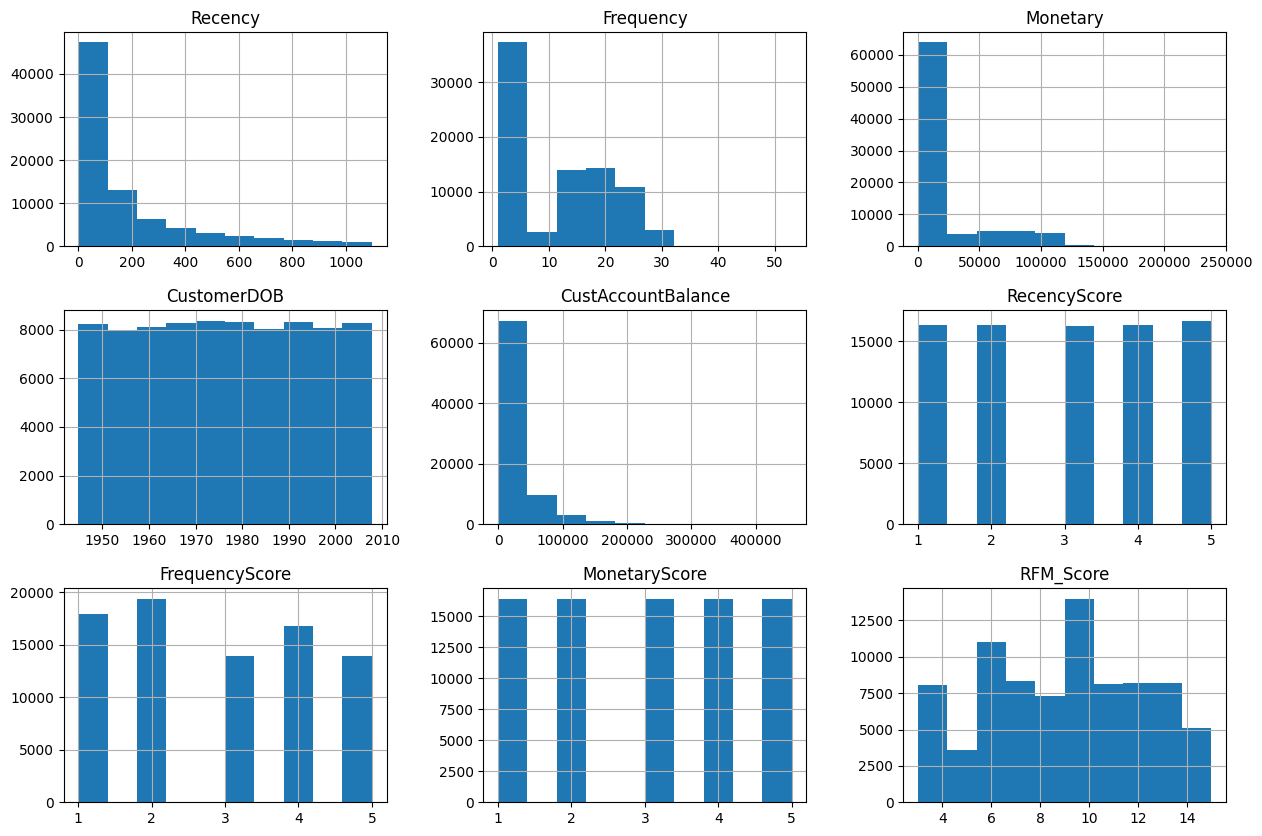

In [59]:
rfm_df.hist(figsize=(15,10))
plt.show()

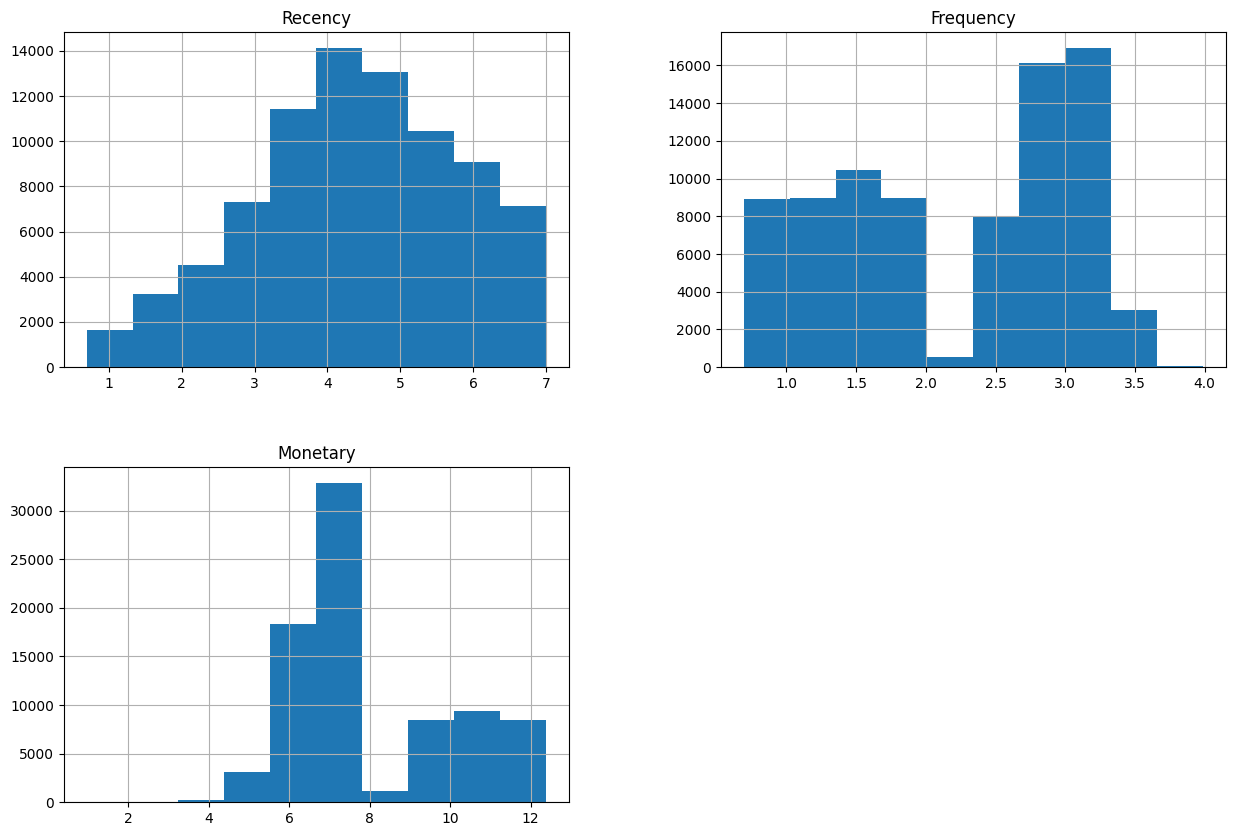

In [60]:
#normalizing the recency, frequency and monetary that by using log1p to convert the skewness to a normal distribution
rfm_clustering = rfm_df[['Recency', 'Frequency', 'Monetary']].copy()

rfm_clustering['Recency'] = np.log1p(rfm_clustering['Recency'])
rfm_clustering['Frequency'] = np.log1p(rfm_clustering['Frequency'])
rfm_clustering['Monetary'] = np.log1p(rfm_clustering['Monetary'])

rfm_clustering.hist(figsize=(15,10))
plt.show()

In [61]:
#standard scaling the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clustering)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.head()

,Recency,Frequency,Monetary
0,1.803285,-1.674215,-1.719173
1,-1.540152,0.894174,-0.539368
2,0.202119,0.712894,-0.674721
3,0.564251,1.228922,-0.343267
4,-0.241104,0.573283,1.596145


RFM analysis was performed to evaluate customer behavior based on transaction recency, transaction frequency, and monetary contribution. Customers were scored using quintile-based ranking, where higher scores represented more valuable and engaged customers. The resulting RFM scores were combined to support customer segmentation and identify distinct behavioral customer groups such as loyal customers, recent customers, and at-risk customers.

#### **Determining the Optimal Number of Clusters**

K-means clustering works through an iterative process of assigning data points to the nearest "center" and then moving those centers to better represent their assigned points.

How K-Means Works "Behind the Scene":

The algorithm follows a simple four-step cycle:

- Initialization: You choose the number of clusters (k) and the algorithm places (k) points (centroids) randomly in your data space.

- Assignment Step: For every single data point, the algorithm calculates the distance (usually Euclidean distance) to each centroid. Each point is assigned to the cluster of its nearest centroid.

- Update Step: The algorithm recalculates each centroid's position by finding the average (mean) of all data points currently assigned to that cluster.

- Repeat: These assignment and update steps repeat until the centroids stop moving or reach a set limit of iterations.

Determining the Optimal Cluster Count

Since you must specify (k) upfront, choosing the right number is critical. The two most common techniques are:

- The Elbow Method: You run K-means for a range of (k) values (e.g., 1–10) and calculate the Inertia (sum of squared distances to the nearest centroid) for each. As (k) increases, inertia always drops, but the "optimal" (k) is where the rate of decrease sharply slows down, forming an "elbow" shape on the plot.

- The Silhouette Method: This measures how similar a point is to its own cluster compared to other clusters. It gives a score between -1 and 1; a high average silhouette score across all points indicates that the data is well-clustered and clearly separated.

In [62]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []
cluster_range = range(2,11)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

    #silhoutte score
    if k>1:
      score = silhouette_score(rfm_scaled_df, kmeans.labels_)
      silhouette_scores.append(score)

print(len(list(cluster_range)))
print(len(wcss))
print(len(silhouette_scores))


9
9
9


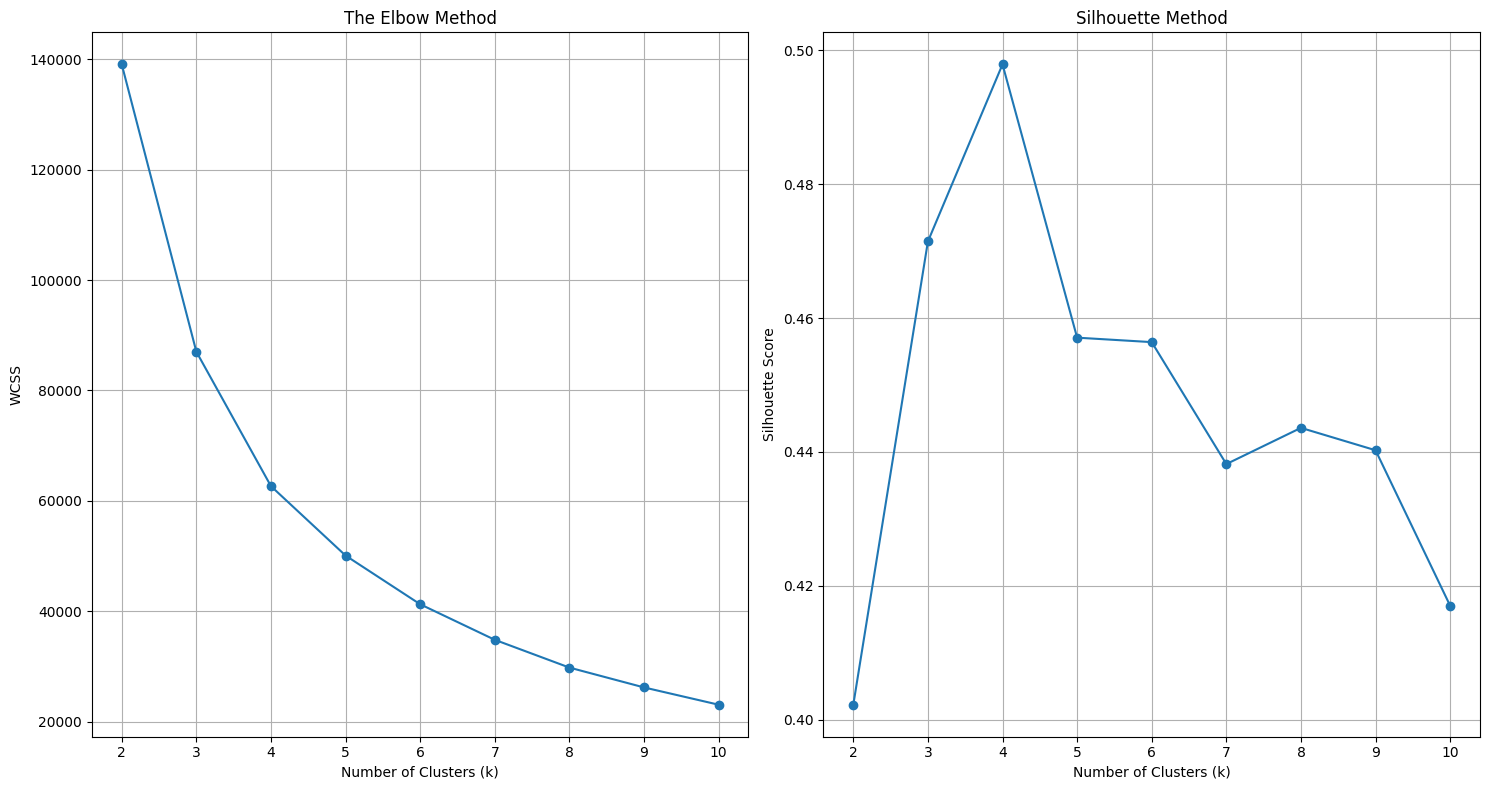

In [63]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
plt.plot(list(cluster_range), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('The Elbow Method')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(list(cluster_range), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/apex_plots/kmeans_clustering.png')
plt.show()

The plots were used to determine the optimal number of clusters for the K-Means customer segmentation model using the Elbow Method and Silhouette Score analysis.

Elbow Method

The Elbow Method plot shows how the Within-Cluster Sum of Squares (WCSS) decreases as the number of clusters increases. WCSS measures how closely grouped the customers are within each cluster. As expected, the WCSS value decreases steadily as more clusters are added because customers become grouped into smaller and more compact clusters.

However, the rate of improvement begins to slow down noticeably around k = 4 or k = 5, creating an “elbow” shape in the curve. This indicates that adding more clusters beyond this point provides diminishing returns and does not significantly improve cluster compactness. Therefore, the Elbow Method suggests that the optimal number of clusters is approximately 4 or 5.

Silhouette Method

The Silhouette Score plot evaluates how well-separated and cohesive the clusters are. Higher silhouette scores indicate better-defined and more distinct clusters. The highest silhouette score was achieved at k = 4, with a score close to 0.50, indicating that customers within each cluster are relatively similar to one another while remaining distinct from customers in other clusters.

After k = 4, the silhouette score gradually declines, suggesting that increasing the number of clusters beyond four reduces the overall quality and separation of the clusters.

Overall Interpretation

Both evaluation methods indicate that 4 clusters is the most suitable number of customer segments for this dataset. The Elbow Method identifies the point where clustering improvements begin to diminish, while the Silhouette Method confirms that four clusters provide the strongest cluster separation and cohesion. As a result, k = 4 was selected as the optimal number of clusters for the customer segmentation analysis.

#### **Applying K-means Clustering and Customer Segmentation**

In [64]:
# applying k_means clustering
optimal_k = 4
print(f"APPLYING KMEAN WITH: {optimal_k}")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(rfm_scaled_df)
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled_df)
rfm_df.head()

APPLYING KMEAN WITH: 4


,CustomerID,Recency,Frequency,Monetary,CustomerDOB,CustGender,CustLocation,CustAccountBalance,RecencyScore,FrequencyScore,MonetaryScore,RFM_Score,Cluster
0,C1000107,1040,1,96.41,2001-06-27,F,South Josh,1150.66,1,1,1,3,3
1,C1000111,8,19,989.46,1952-11-18,M,New Peter,52895.11,5,4,2,11,1
2,C1000159,106,16,758.07,1988-07-23,M,Lake Duncanburgh,3006.98,3,4,2,9,1
3,C1000852,178,26,1455.31,1985-10-06,M,Thomasborough,11922.49,2,5,4,11,1
4,C1000896,56,14,65914.10,1945-04-10,M,East Kim,43815.21,4,3,5,12,0


In [65]:
rfm_df['Cluster'].value_counts().reset_index()

,Cluster,count
0,1,31938
1,3,22544
2,0,15384
3,2,12134


#### **Customer Segmentation Visualization and Cluster Profiling**

In [66]:
cluster_analysis = rfm_df.groupby('Cluster').agg({'Recency': 'mean',
                                                  'Frequency': 'mean',
                                                  'Monetary': 'mean',
                                                  'RecencyScore': 'mean',
                                                  'FrequencyScore': 'mean',
                                                  'MonetaryScore':'mean',
                                                  'CustomerID':'count',
                                                  'CustAccountBalance':'mean',
                                                  'CustGender':lambda x: x.mode
                                                  ()[0] if len (x.mode()
                                                  ) > 0 else 'Unknown'}).round(2)
#cluster analysis columns
cluster_analysis.columns = ['AvgRecency', 'AvgFrequency', 'AvgMonetary', 'AvgRecencyScore', 'AvgFrequencyScore', 'AvgMonetaryScore', 'CustomerCount', 'AvgCustAccountBalance', 'MostCommonGender']
cluster_analysis = cluster_analysis.reset_index()

cluster_analysis['percentage'] = (cluster_analysis['CustomerCount']/cluster_analysis['CustomerCount'].sum()) * 100
cluster_analysis['percentage'] = cluster_analysis['percentage'] .round(2)
cluster_analysis.head()

,Cluster,AvgRecency,AvgFrequency,AvgMonetary,AvgRecencyScore,AvgFrequencyScore,AvgMonetaryScore,CustomerCount,AvgCustAccountBalance,MostCommonGender,percentage
0,0,65.94,16.02,79876.94,3.72,3.64,4.98,15384,16342.05,M,18.76
1,1,50.22,18.74,1012.16,3.95,3.99,2.52,31938,27359.23,F,38.95
2,2,435.37,1.81,17882.34,1.64,1.20,4.11,12134,24737.52,M,14.80
3,3,315.94,3.59,680.85,1.92,1.67,1.74,22544,28086.71,M,27.49


In [68]:
#Assigning cluster names to each cluster or customer category
def assign_name_to_cluster(stats):
  recency = stats['AvgRecency']
  frequency = stats['AvgFrequency']
  monetary = stats['AvgMonetary']

  #if customer has not made any transaction in a year or above
  if recency > 365:
    if monetary > 20000:
      return "High-value dormant customer"
    else:
      return "Low-value dormant customer"

  #if customer has not made any trasaction within six months or above
  if recency > 180:
    if monetary > 20000:
      return "High-value inactive customer"
    else:
      return "Low-value inactive customer"

  if frequency > 10 and monetary > 30000:
    return "High-value loyal customer"
  elif frequency > 8 and monetary < 10000:
    return "Low-value loyal customer"
  else:
    return "Regular customer"

rfm_df['Cluster_Name'] = rfm_df['Cluster'].map(lambda x: assign_name_to_cluster(cluster_analysis.loc[x]))
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,CustomerDOB,CustGender,CustLocation,CustAccountBalance,RecencyScore,FrequencyScore,MonetaryScore,RFM_Score,Cluster,Cluster_Name
0,C1000107,1040,1,96.41,2001-06-27,F,South Josh,1150.66,1,1,1,3,3,Low-value inactive customer
1,C1000111,8,19,989.46,1952-11-18,M,New Peter,52895.11,5,4,2,11,1,Low-value loyal customer
2,C1000159,106,16,758.07,1988-07-23,M,Lake Duncanburgh,3006.98,3,4,2,9,1,Low-value loyal customer
3,C1000852,178,26,1455.31,1985-10-06,M,Thomasborough,11922.49,2,5,4,11,1,Low-value loyal customer
4,C1000896,56,14,65914.10,1945-04-10,M,East Kim,43815.21,4,3,5,12,0,High-value loyal customer


In [69]:
cluster_distribution = rfm_df["Cluster_Name"].value_counts().reset_index()
cluster_distribution.columns = ["Cluster_Name", "Count"]


In [70]:
cluster_profile = rfm_df.groupby("Cluster_Name").agg({"Recency": "mean",
                                                    "Frequency": "mean",
                                                    "Monetary": "mean",
                                                    "CustAccountBalance": "mean",
                                                    "CustomerID": "count"}).round(2)
cluster_profile.columns = ["AvgRecency", "AvgFrequency", "AvgMonetary", "AvgCustAccountBalance", "CustomerCount"]

cluster_profile = cluster_profile.reset_index()
cluster_profile["Percentage"] = (cluster_profile["CustomerCount"] / cluster_profile["CustomerCount"].sum()) * 100
cluster_profile["Percentage"] = cluster_profile["Percentage"].round(2)

cluster_profile.head()

,Cluster_Name,AvgRecency,AvgFrequency,AvgMonetary,AvgCustAccountBalance,CustomerCount,Percentage
0,High-value loyal customer,65.94,16.02,79876.94,16342.05,15384,18.76
1,Low-value dormant customer,435.37,1.81,17882.34,24737.52,12134,14.80
2,Low-value inactive customer,315.94,3.59,680.85,28086.71,22544,27.49
3,Low-value loyal customer,50.22,18.74,1012.16,27359.23,31938,38.95


In [71]:
cluster_profile.shape

(4, 7)

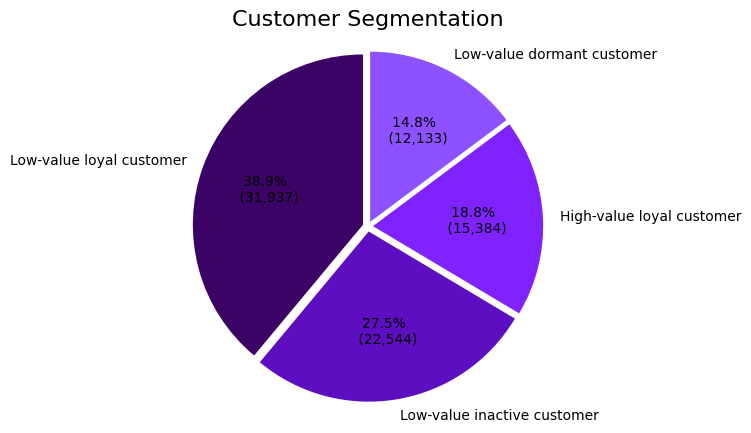

In [76]:
#Customer Segmentation Distribution Visualization
color = ["#3C0366", "#5D0EC0", "#7F22FE", "#8E51FF", "#A684FF"]

segment_counts = rfm_df['Cluster_Name'].value_counts()

plt.figure(figsize = (8,5))
explode = [0.03] * len(segment_counts)

plt.pie(segment_counts.values,
        labels = segment_counts.index,
        autopct = lambda p: f'{p:.1f}% \n ({int(p*sum(segment_counts.values)/100):,})',
        startangle = 90,
        explode = explode,
        colors = color[:len(segment_counts)],
        shadow =  False)

plt.title("Customer Segmentation", fontsize = 16)
plt.axis("equal")
plt.show()

<Figure size 800x500 with 0 Axes>

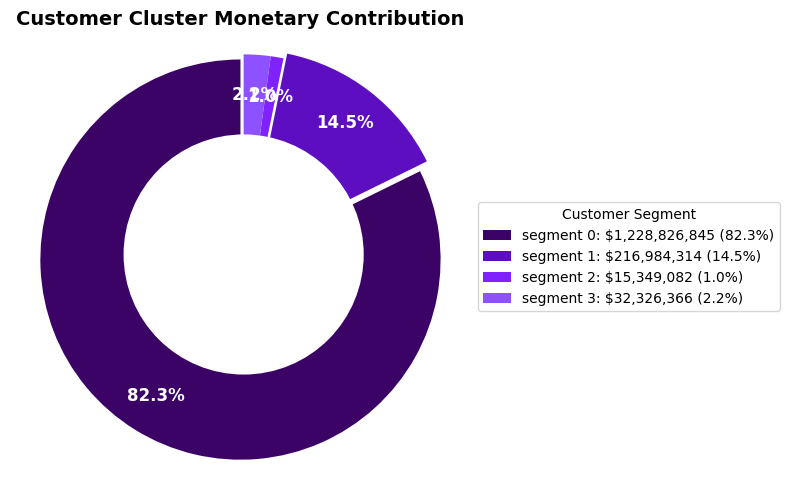

In [79]:
#Customer Segment Total Monetary Value Distribution
plt.figure(figsize = (8,5))

fig, ax = plt.subplots(figsize = (8,5))
df = cluster_profile.copy()

df['Total_Monetary_Contribution'] = df['AvgMonetary'] * df['CustomerCount']

n_segments = len(df)
explode = [0.03 if i < 2 else 0 for i in range(n_segments)]

#creating a donut chart
wedges, texts, autotexts = ax.pie(df['Total_Monetary_Contribution'],
                                  labels=None,
                                  autopct=lambda p: f'{p:.1f}%',
                                  explode=explode,
                                  colors=color,
                                  pctdistance=0.8,
                                  startangle=90,
                                  textprops={'fontsize':11, 'fontweight':'bold'})

# Adding the Center circle to make the doughnut chart
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

#Making percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

#Create legend with detailed info
legend_labels = []
for segment in cluster_profile.index:
    total = df.loc[segment, 'Total_Monetary_Contribution']
    pct = total / df['Total_Monetary_Contribution'].sum() * 100
    legend_labels.append(f'segment {segment}: ${total:,.0f} ({pct:.1f}%)')

plt.legend(wedges,
           legend_labels,
           title="Customer Segment",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)

# Title
plt.title('Customer Cluster Monetary Contribution', fontsize=14, fontweight='bold')

# Equal aspect ratio
plt.axis('equal')

plt.tight_layout()

# Save figure
plt.savefig('cluster_monetary_contribution.png', dpi=300, bbox_inches='tight')

plt.show()

In [80]:
cluster_profile.head()

,Cluster_Name,AvgRecency,AvgFrequency,AvgMonetary,AvgCustAccountBalance,CustomerCount,Percentage
0,High-value loyal customer,65.94,16.02,79876.94,16342.05,15384,18.76
1,Low-value dormant customer,435.37,1.81,17882.34,24737.52,12134,14.80
2,Low-value inactive customer,315.94,3.59,680.85,28086.71,22544,27.49
3,Low-value loyal customer,50.22,18.74,1012.16,27359.23,31938,38.95


In [81]:
cluster_profile['Cluster_Name'] = cluster_profile.index
cluster_profile['Total_Revenue'] = (cluster_profile['AvgMonetary'] * cluster_profile['CustomerCount'])
cluster_profile.head()

,Cluster_Name,AvgRecency,AvgFrequency,AvgMonetary,AvgCustAccountBalance,CustomerCount,Percentage,Total_Revenue
0,0,65.94,16.02,79876.94,16342.05,15384,18.76,1.228827e+09
1,1,435.37,1.81,17882.34,24737.52,12134,14.80,2.169843e+08
2,2,315.94,3.59,680.85,28086.71,22544,27.49,1.534908e+07
3,3,50.22,18.74,1012.16,27359.23,31938,38.95,3.232637e+07


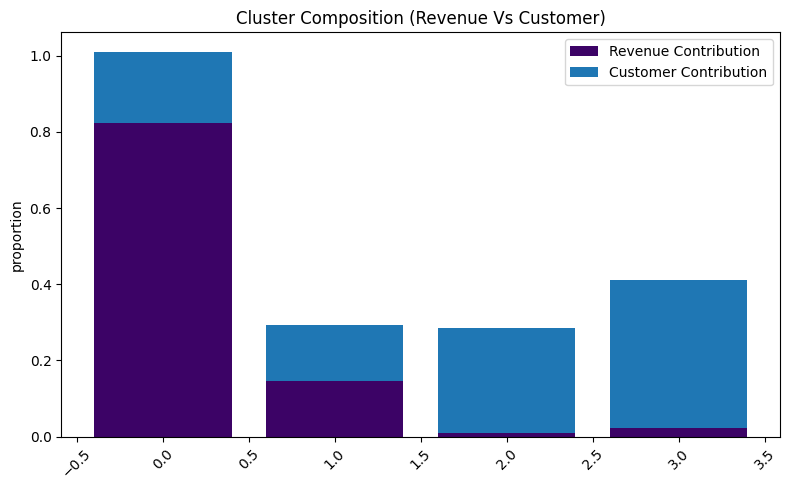

In [83]:
#visualization
cluster = cluster_profile['Cluster_Name']
revenue = cluster_profile['Total_Revenue']
customer = cluster_profile['CustomerCount']

#normalizing for stacking
revenue_norm = revenue / revenue.sum()
customer_norm = customer / customer.sum()

plt.figure(figsize=(8,5))
plt.bar(cluster, revenue_norm, color='#3C0366', label='Revenue Contribution')
plt.bar(cluster, customer_norm, bottom=revenue_norm, label='Customer Contribution')

plt.xticks(rotation=45)
plt.ylabel('proportion')
plt.title('Cluster Composition (Revenue Vs Customer)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Average RFM value per segment

In [ ]:
#using radar chart to visualize customers behaviour

In [ ]:
#Using horizontal bar chart for segment sizes